# 04 - Multi-Horizon Feature Engineering

This notebook refactors the project feature store into a **research-grade early-warning foundation**.

## Goals
1. Build leakage-safe predictive features at **day 7, 14, 21, and 30**.
2. Keep the project grain fixed at `id_student + code_module + code_presentation`.
3. Preserve the existing day-30 segmentation and recommendation outputs for notebook 05.
4. Export metadata that shows coverage, missingness, and schema consistency across horizons.

**Main outputs**
- `features_prediction_day07.csv`
- `features_prediction_day14.csv`
- `features_prediction_day21.csv`
- `features_prediction_day30.csv`
- `features_horizon_metadata.csv`
- `features_final.csv`, `features_segmentation.csv`, `features_prediction.csv`, `features_recommendation.csv`

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

ROOT = find_repo_root()
PROCESSED = ROOT / 'data' / 'processed'
sys.path.append(str(ROOT))

from src.features import build_multi_horizon_feature_store

HORIZONS = (7, 14, 21, 30)
ROOT, PROCESSED

(PosixPath('/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project'),
 PosixPath('/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project/data/processed'))

## 1. Build the feature store

The heavy lifting now lives in `src/features/multi_horizon_feature_store.py`.
That module computes the feature store once, writes the horizon-specific prediction tables, and keeps the day-30 outputs required by notebook 05.

In [2]:
outputs = build_multi_horizon_feature_store(
    processed_dir=PROCESSED,
    horizons=HORIZONS,
    early_window_cap=14,
    write_outputs=True,
)

metadata = outputs.features_horizon_metadata.copy()
display(metadata)

print('Saved horizon-specific prediction tables:')
for horizon, table in outputs.prediction_tables.items():
    print(f'  features_prediction_day{horizon:02d}.csv -> {table.shape}')

print('\nSaved downstream day-30 tables:')
print(f'  features_final.csv          -> {outputs.features_final.shape}')
print(f'  features_segmentation.csv   -> {outputs.features_segmentation.shape}')
print(f'  features_prediction.csv     -> {outputs.features_prediction.shape}')
print(f'  features_recommendation.csv -> {outputs.features_recommendation.shape}')

,horizon_day,rows,raw_missing_pct_pre_imputation,post_imputation_missing_pct,observed_activity_rate,submission_coverage,score_coverage,available_assessment_rate,delay_imputation_value,at_risk_rate,prediction_columns,numeric_model_features,categorical_dummy_features
0,7,32593,26.0577,0.0000,0.7401,0.0274,0.0273,0.4570,19.0000,0.5280,40,17,18
1,14,32593,22.7700,0.0000,0.8155,0.1034,0.1032,0.4570,9.0000,0.5280,40,17,18
2,21,32593,15.2400,0.0000,0.8467,0.4675,0.4673,0.5765,1.0000,0.5280,40,17,18
3,30,32593,10.9161,0.0000,0.8582,0.6379,0.6375,0.8322,1.0000,0.5280,40,17,18


Saved horizon-specific prediction tables:
  features_prediction_day07.csv -> (32593, 40)
  features_prediction_day14.csv -> (32593, 40)
  features_prediction_day21.csv -> (32593, 40)
  features_prediction_day30.csv -> (32593, 40)

Saved downstream day-30 tables:
  features_final.csv          -> (32593, 38)
  features_segmentation.csv   -> (32593, 13)
  features_prediction.csv     -> (32593, 40)
  features_recommendation.csv -> (32593, 13)


## 2. Horizon coverage and leakage control

Each horizon is built from the same enrollment list, but the behavior and assessment coverage increase as more course time is allowed.
This is the main research trade-off: **earlier detection gives more intervention time, but less signal**.

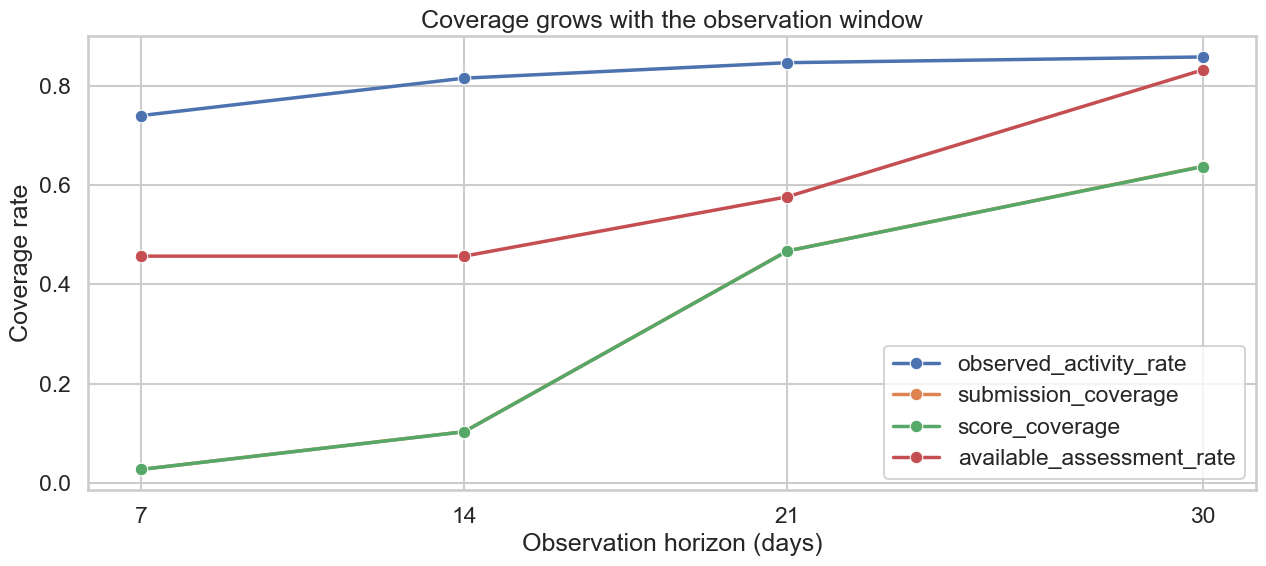

In [3]:
coverage_cols = [
    'observed_activity_rate',
    'submission_coverage',
    'score_coverage',
    'available_assessment_rate',
]

plot_df = metadata[['horizon_day'] + coverage_cols].melt(
    id_vars='horizon_day',
    var_name='coverage_metric',
    value_name='coverage_rate',
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=plot_df, x='horizon_day', y='coverage_rate', hue='coverage_metric', marker='o', linewidth=2.5, ax=ax)
ax.set_title('Coverage grows with the observation window')
ax.set_xlabel('Observation horizon (days)')
ax.set_ylabel('Coverage rate')
ax.set_xticks(list(HORIZONS))
ax.legend(title='')
plt.tight_layout()

## 3. Schema verification

The prediction tables must stay aligned across horizons so notebook 06 can compare models fairly without schema drift.

In [4]:
schema_rows = []
reference_columns = None

for horizon, table in outputs.prediction_tables.items():
    key_duplicates = int(table.duplicated(subset=['id_student', 'code_module', 'code_presentation']).sum())
    missing_cells = int(table.isna().sum().sum())
    schema_rows.append({
        'horizon_day': horizon,
        'rows': len(table),
        'columns': table.shape[1],
        'duplicate_enrollment_keys': key_duplicates,
        'missing_cells': missing_cells,
    })
    if reference_columns is None:
        reference_columns = table.columns.tolist()
    else:
        assert reference_columns == table.columns.tolist(), f'Schema mismatch at horizon {horizon}'

schema_check = pd.DataFrame(schema_rows).sort_values('horizon_day')
display(schema_check)

,horizon_day,rows,columns,duplicate_enrollment_keys,missing_cells
0,7,32593,40,0,0
1,14,32593,40,0,0
2,21,32593,40,0,0
3,30,32593,40,0,0


## 4. Day-30 feature sets kept for notebook 05

The research refactor does **not** change the project architecture downstream:
- notebook 05 still uses the day-30 segmentation and recommendation tables,
- notebook 06 now uses the new horizon-specific prediction tables.

In [5]:
inventory = pd.DataFrame([
    {'dataset': 'features_final.csv', 'rows': outputs.features_final.shape[0], 'columns': outputs.features_final.shape[1], 'role': 'Reference day-30 feature table'},
    {'dataset': 'features_segmentation.csv', 'rows': outputs.features_segmentation.shape[0], 'columns': outputs.features_segmentation.shape[1], 'role': 'Scaled clustering inputs for notebook 05'},
    {'dataset': 'features_prediction.csv', 'rows': outputs.features_prediction.shape[0], 'columns': outputs.features_prediction.shape[1], 'role': 'Day-30 prediction alias for backward compatibility'},
    {'dataset': 'features_recommendation.csv', 'rows': outputs.features_recommendation.shape[0], 'columns': outputs.features_recommendation.shape[1], 'role': 'MinMax-scaled recommendation inputs for notebook 05'},
])
display(inventory)

,dataset,rows,columns,role
0,features_final.csv,32593,38,Reference day-30 feature table
1,features_segmentation.csv,32593,13,Scaled clustering inputs for notebook 05
2,features_prediction.csv,32593,40,Day-30 prediction alias for backward compatibi...
3,features_recommendation.csv,32593,13,MinMax-scaled recommendation inputs for notebo...


## 5. Takeaway

The project now has a **single day-30 branch for segmentation/recommendation** and a **four-horizon branch for research-grade early-warning modeling**.

That split matches the new project direction:
- notebook 05 remains an interpretable day-30 analytics layer,
- notebook 06 becomes the center of the multi-horizon early-warning study.